<a href="https://colab.research.google.com/github/TejashwiniByrappa/Tejashwini-landing-page/blob/main/online_shopping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Online Shopper Dataset generated successfully!
Dataset Shape: (2500, 10)
   Administrative_Duration  Informational_Duration  ProductRelated_Duration  \
0                    23.46                   52.72                   100.05   
1                   150.51                   43.38                   128.28   
2                    65.84                   25.57                   385.58   
3                    45.65                   93.74                    83.10   
4                     8.48                    6.71                   407.51   

   BounceRates  ExitRates  PageValues  SpecialDay        VisitorType  Weekend  \
0       0.0457     0.1143        0.00         0.0  Returning_Visitor        1   
1       0.0216     0.0818        0.00         1.0  Returning_Visitor        0   
2       0.1272     0.1617       10.47         1.0  Returning_Visitor        1   
3       0.0101     0.0715        0.00         0.0  Returning_Visitor        0   
4       0.0145     0.0903        0.00         0

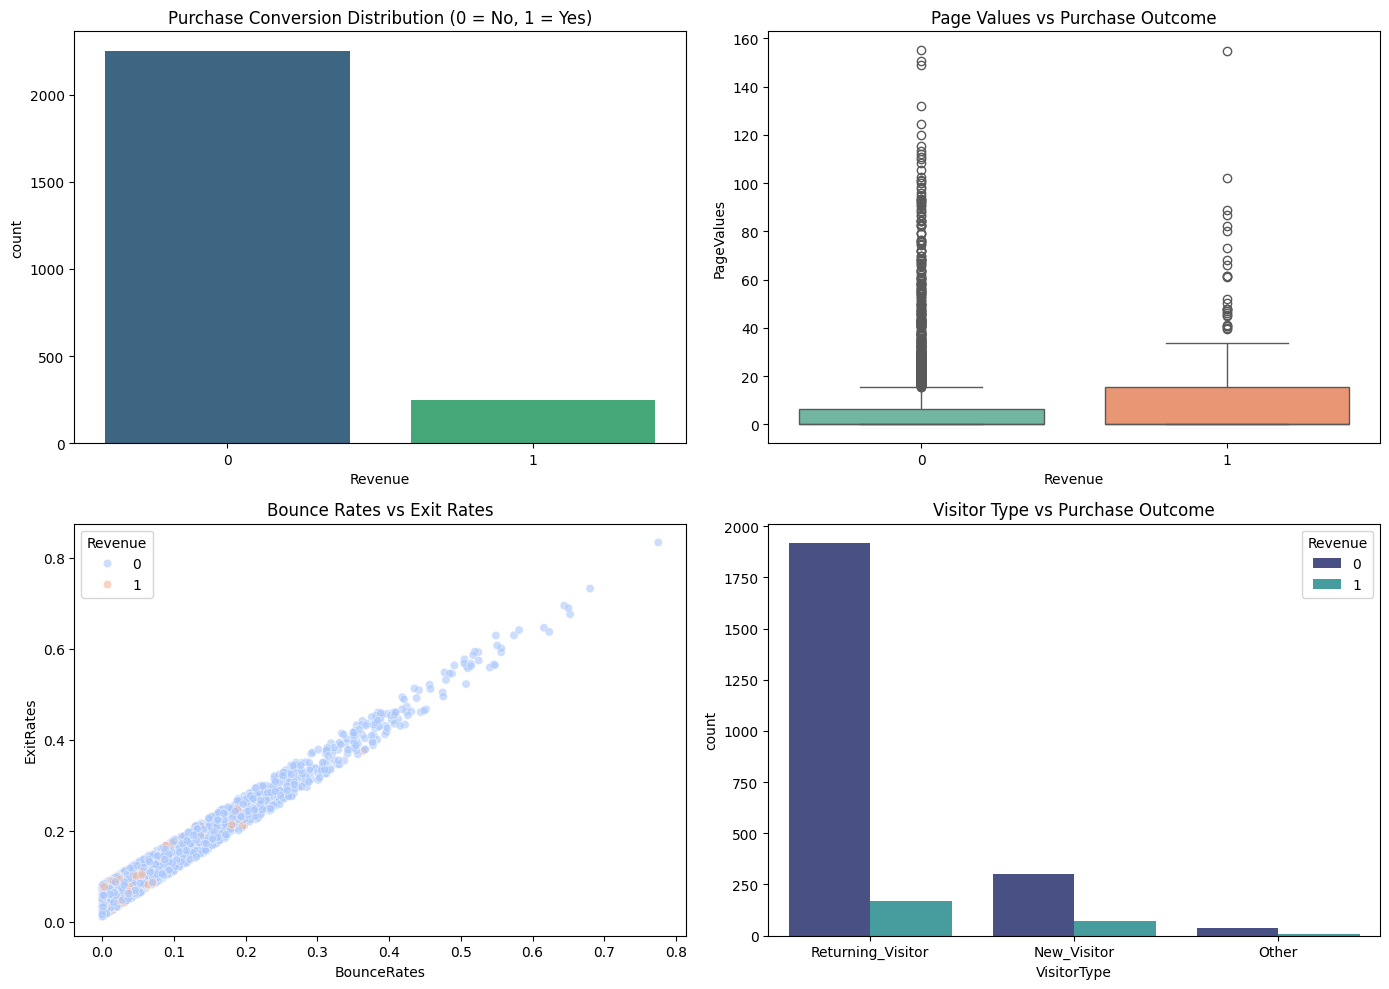

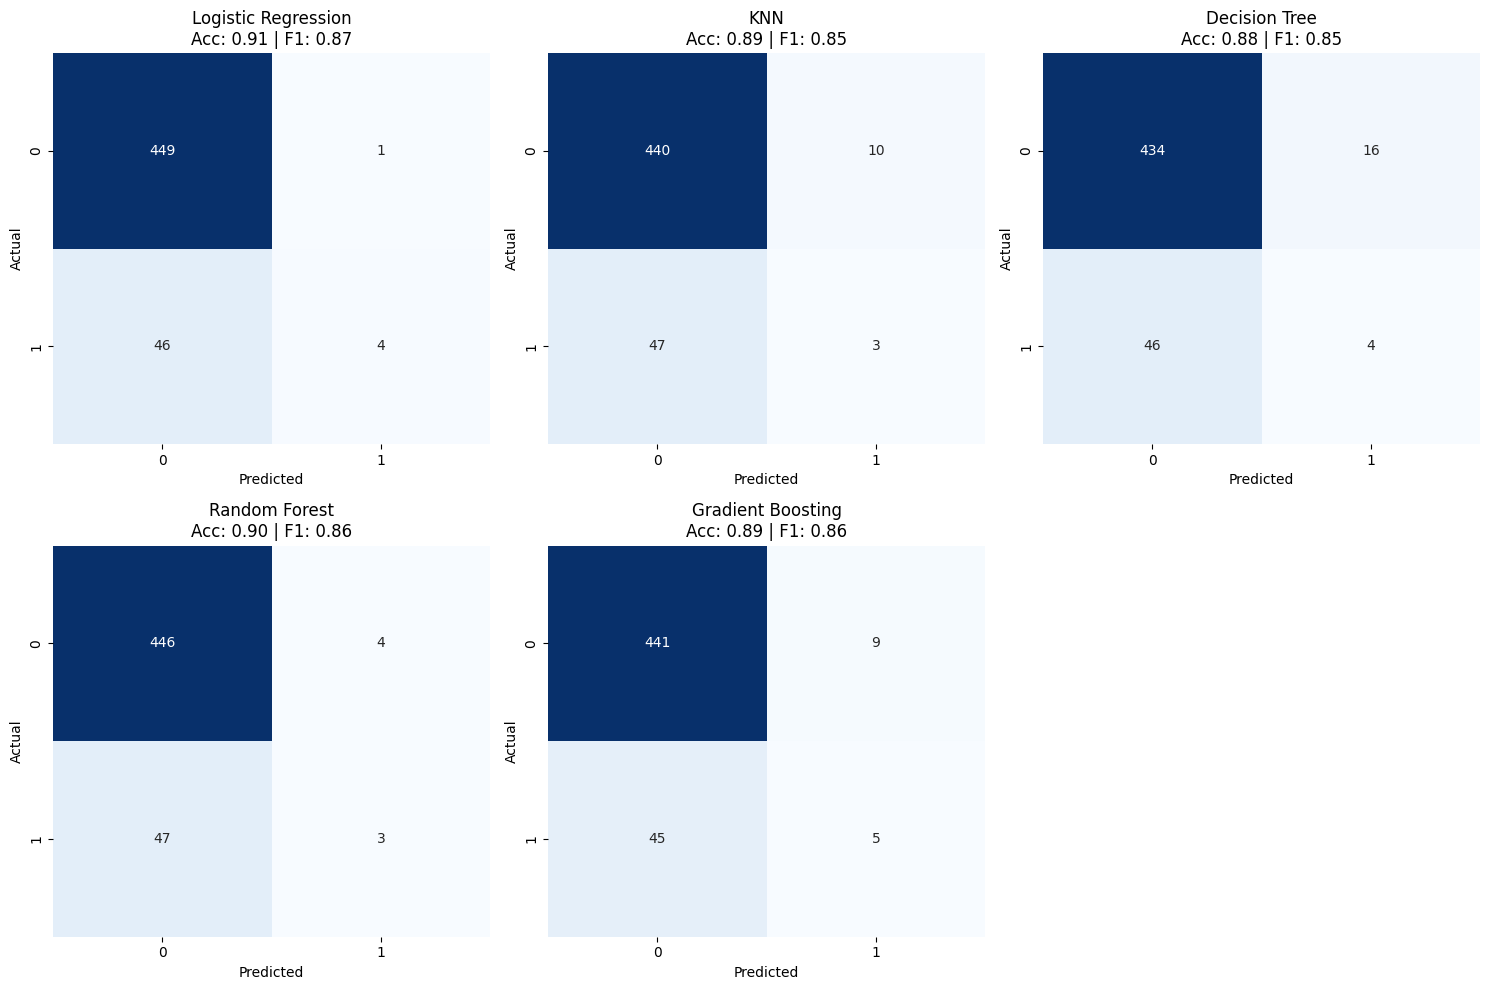

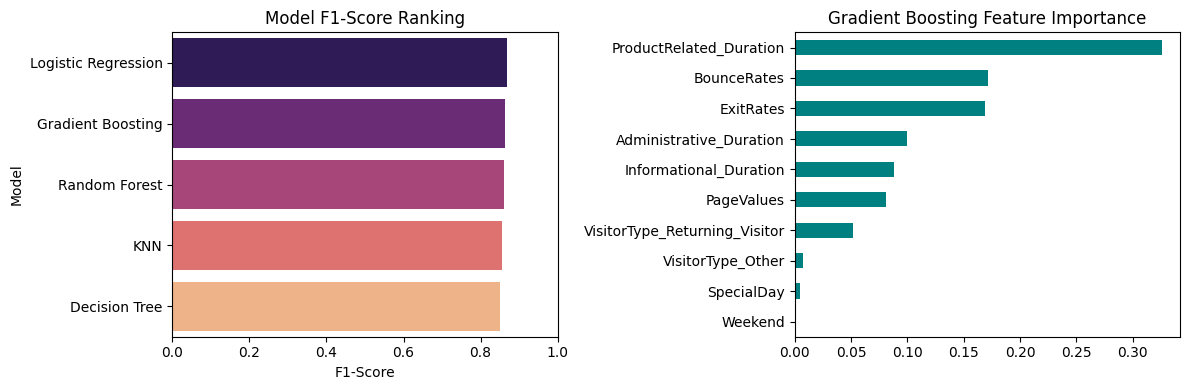


=== SHOPPER PURCHASE PREDICTION MODEL RANKING ===
              Model  Accuracy  F1-Score  Precision  Recall
Logistic Regression     0.906  0.869784   0.800000    0.08
  Gradient Boosting     0.892  0.863702   0.357143    0.10
      Random Forest     0.898  0.861852   0.428571    0.06
                KNN     0.886  0.854775   0.230769    0.06
      Decision Tree     0.876  0.851429   0.200000    0.08


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

warnings.simplefilter(action='ignore', category=FutureWarning)

# ==========================================
# 1. GENERATE SYNTHETIC E-COMMERCE DATASET
# ==========================================
np.random.seed(42)
n_samples = 2500

# Browsing duration & web metrics
admin_duration = np.random.exponential(scale=50, size=n_samples).round(2)
info_duration = np.random.exponential(scale=30, size=n_samples).round(2)
product_duration = np.random.exponential(scale=200, size=n_samples).round(2)

bounce_rates = np.random.beta(a=0.5, b=5, size=n_samples).round(4)
exit_rates = bounce_rates + np.random.uniform(0.01, 0.08, size=n_samples).round(4)

# PageValues is a strong predictor of purchase intention
page_values = np.where(np.random.rand(n_samples) < 0.7, 0, np.random.exponential(scale=25, size=n_samples)).round(2)

visitor_type = np.random.choice(['Returning_Visitor', 'New_Visitor', 'Other'], size=n_samples, p=[0.82, 0.16, 0.02])
weekend = np.random.choice([0, 1], size=n_samples, p=[0.7, 0.3])
special_day = np.random.choice([0.0, 0.2, 0.6, 0.8, 1.0], size=n_samples, p=[0.8, 0.08, 0.05, 0.04, 0.03])

# Generating 'Revenue' target (1 = Purchased, 0 = Left without buying)
conversion_prob = (
    0.05
    + 0.025 * np.log1p(page_values)
    + 0.0005 * product_duration
    - 1.5 * bounce_rates
    + 0.1 * (visitor_type == 'New_Visitor')
)
conversion_prob = np.clip(conversion_prob, 0.01, 0.95)
revenue = np.random.binomial(1, conversion_prob)

df = pd.DataFrame({
    'Administrative_Duration': admin_duration,
    'Informational_Duration': info_duration,
    'ProductRelated_Duration': product_duration,
    'BounceRates': bounce_rates,
    'ExitRates': exit_rates,
    'PageValues': page_values,
    'SpecialDay': special_day,
    'VisitorType': visitor_type,
    'Weekend': weekend,
    'Revenue': revenue
})

print("Online Shopper Dataset generated successfully!")
print(f"Dataset Shape: {df.shape}")
print(df.head())


# ==========================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
plt.figure(figsize=(14, 10))

# Graph 1: Revenue Target Distribution
plt.subplot(2, 2, 1)
sns.countplot(x="Revenue", data=df, hue="Revenue", palette="viridis", legend=False)
plt.title("Purchase Conversion Distribution (0 = No, 1 = Yes)")

# Graph 2: PageValues vs Revenue
plt.subplot(2, 2, 2)
sns.boxplot(x="Revenue", y="PageValues", data=df, hue="Revenue", palette="Set2", legend=False)
plt.title("Page Values vs Purchase Outcome")

# Graph 3: Bounce Rates vs Exit Rates by Revenue
plt.subplot(2, 2, 3)
sns.scatterplot(x="BounceRates", y="ExitRates", hue="Revenue", data=df, alpha=0.6, palette="coolwarm")
plt.title("Bounce Rates vs Exit Rates")

# Graph 4: Visitor Type vs Purchase Conversion
plt.subplot(2, 2, 4)
sns.countplot(x="VisitorType", hue="Revenue", data=df, palette="mako")
plt.title("Visitor Type vs Purchase Outcome")

plt.tight_layout()
plt.show()


# ==========================================
# 3. PREPROCESSING & FEATURE ENCODING
# ==========================================
X = df.drop(columns=["Revenue"])
y = df["Revenue"]

# One-hot encode categorical features ('VisitorType')
X_encoded = pd.get_dummies(X, drop_first=True)

# Train-Test Split with stratification for imbalanced targets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ==========================================
# 4. MODEL TRAINING & EVALUATION
# ==========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=6),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1-Score": f1,
        "Precision": prec,
        "Recall": rec
    })

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx], cbar=False)
    axes[idx].set_title(f"{name}\nAcc: {acc:.2f} | F1: {f1:.2f}")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

axes[5].axis("off")
plt.tight_layout()
plt.show()


# ==========================================
# 5. MODEL RANKING & FEATURE IMPORTANCE
# ==========================================
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)

plt.figure(figsize=(12, 4))

# Chart 1: F1-Score Comparison
plt.subplot(1, 2, 1)
sns.barplot(x="F1-Score", y="Model", data=results_df, hue="Model", palette="magma", legend=False)
plt.title("Model F1-Score Ranking")
plt.xlim(0, 1)

# Chart 2: Feature Importance from Gradient Boosting
gb_model = models["Gradient Boosting"]
importances = pd.Series(gb_model.feature_importances_, index=X_encoded.columns).sort_values(ascending=True)

plt.subplot(1, 2, 2)
importances.plot(kind="barh", color="teal")
plt.title("Gradient Boosting Feature Importance")

plt.tight_layout()
plt.show()

print("\n=== SHOPPER PURCHASE PREDICTION MODEL RANKING ===")
print(results_df.to_string(index=False))